```
uv pip install numpy uproot pandas matplotlib hist scipy ipykernel scikit-learn
```

In [ ]:
#plotting data from multiple root files

import hist
from hist import Hist
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import uproot
import mplhep


particles = ["p", "pi", "kaon"]
branches = ["chi2Sum", "eQOP_fit", "eT_fit", "err_eQOP_fit", "err_eT_fit", "res_eQOP_fit", "res_eT_fit",
            "pull_eQOP_fit", "pull_eT_fit"
]
xmins = [0, -1, -200, 0, 0, -0.1, -200, -13, -50]
xmaxs = [200, 1, 200, 0.06, 20, 0.1, 200, 13, 50]

ranges = zip(branches, xmins, xmaxs)


def do_assumption(branch, hypo):
    spectrums = dict()

    for truth in particles:
        filename = f"/workspaces/acts/tracksummary_kf_h_{hypo}_t_{truth}.root"
        with uproot.open(filename) as file:
            variable = file["tracksummary"][branch]
            raw = variable.array(library="ak")
            spectrums[truth] = ak.flatten(raw)

    return spectrums


for branch, xmin, xmax in ranges:
    for hypo in particles:
        fig, ax = plt.subplots(figsize=(8, 6))
        specs = do_assumption(branch, hypo)

        for truth in specs:
            container = Hist(hist.axis.Regular(100, xmin, xmax, name = branch))
            container.fill(**{branch:specs[truth]})
            container.plot1d(ax=ax, lw=1, label=truth)

        ax.legend()
        ax.set_title(hypo)
        fig.savefig(f"pics hypo/{branch}_h_{hypo}")
        plt.show()


In [ ]:
#plotting 2d histograms

particles = ["p", "pi", "kaon"]
branches = ["chi2Sum", "eQOP_fit", "eT_fit", "err_eQOP_fit", "err_eT_fit", "res_eQOP_fit", "res_eT_fit"
]
xmins = [0, -1, -70, 0, 0, -0.1, -70]
xmaxs = [150, 1, 70, 0.02, 20, 0.1, 70]

ranges = list(zip(branches, xmins, xmaxs))

chi2 = ranges[0]
err_qop = ranges[3]

for ptcl in particles:
    fig, ax = plt.subplots(figsize=(8, 6))
    filename = f"/workspaces/acts/tracksummary_kf_h_{ptcl}_t_{ptcl}.root"
    with uproot.open(filename) as file:
        qop = file["tracksummary"][err_qop[0]]
        chi = file["tracksummary"][chi2[0]]

        hist2d = hist.Hist(
            hist.axis.Regular(200, err_qop[1], err_qop[2], name = err_qop[0]),
            hist.axis.Regular(200, chi2[1], chi2[2], name=chi2[0])
        )

        hist_qop = ak.flatten(qop.array(library="ak"))
        hist_chi = ak.flatten(chi.array(library="ak"))

        hist2d.fill(hist_qop, hist_chi)
        hist2d.plot2d(ax=ax)
        ax.set_title(f"Hypo = {ptcl}, Truth = {ptcl}")
        fig.savefig(f"chi2 vs eqop/h_{ptcl}_t_{ptcl}.png")

    

In [ ]:
#KNN implementation

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap


cmap_light = ListedColormap(["#FF4444", "#44FF44", "#4444FF"])
cmap_bold = ListedColormap(["#FF0000", "#00FF00", "#0000FF"])
axis = plt.subplot()

iris = load_iris()
x = iris.data[:, :2]
y = iris.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4)

classifier = KNeighborsClassifier(5)
classifier.fit(x_train, y_train)

DecisionBoundaryDisplay.from_estimator(classifier, x, cmap=cmap_light, ax=axis, response_method="predict")
axis.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap_bold, edgecolors="k")
plt.show()

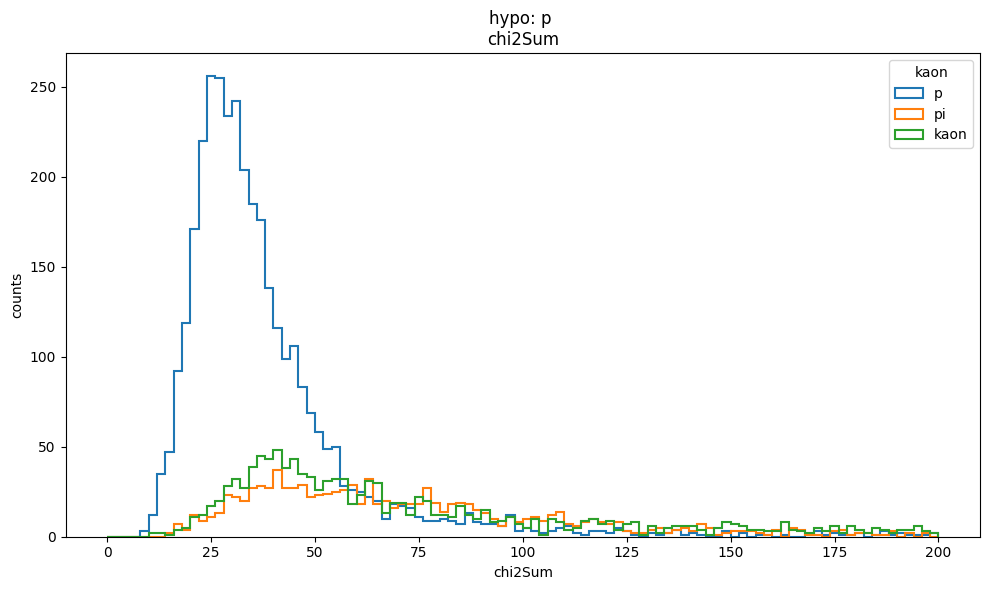

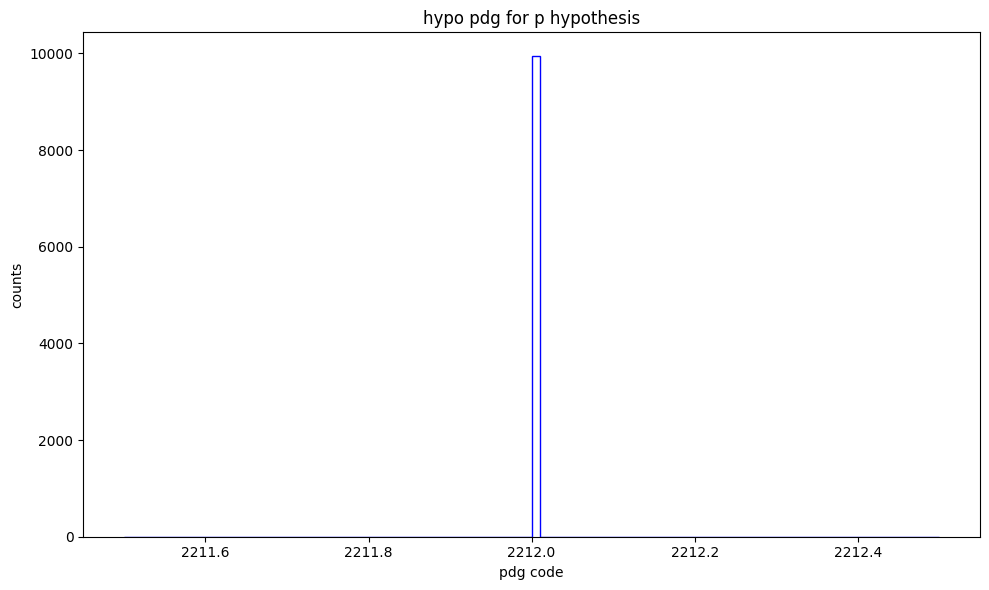

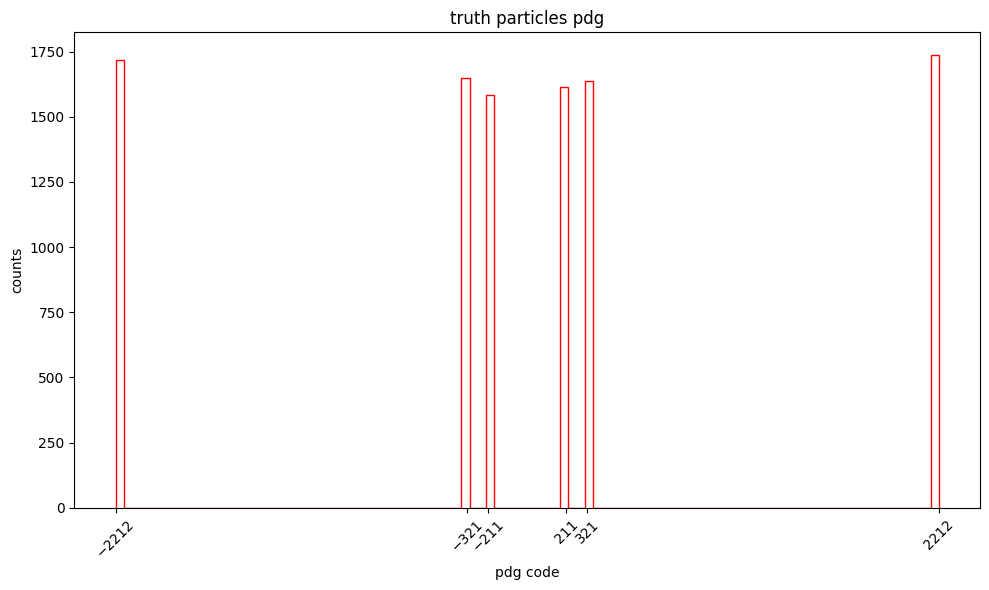

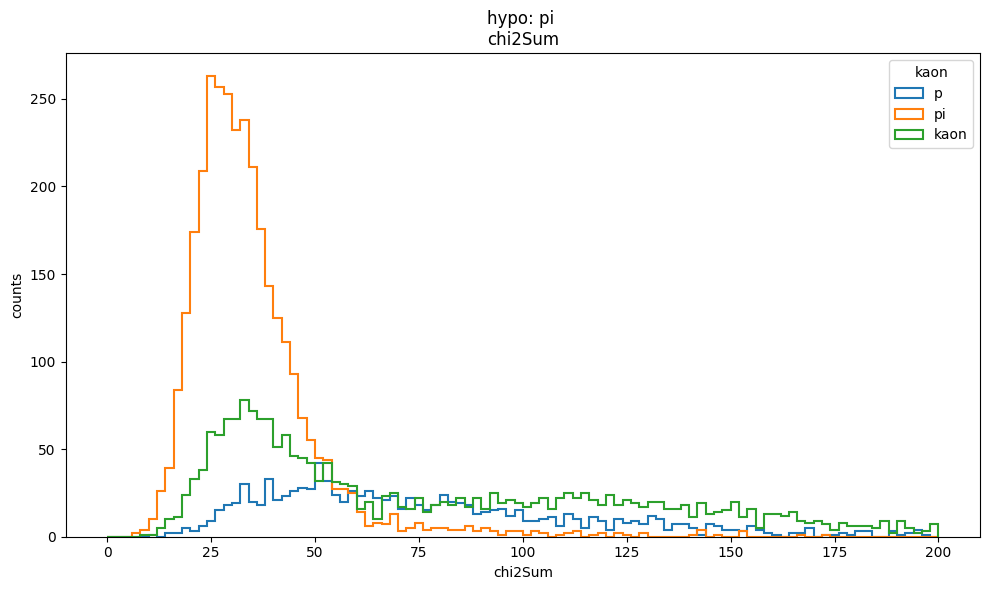

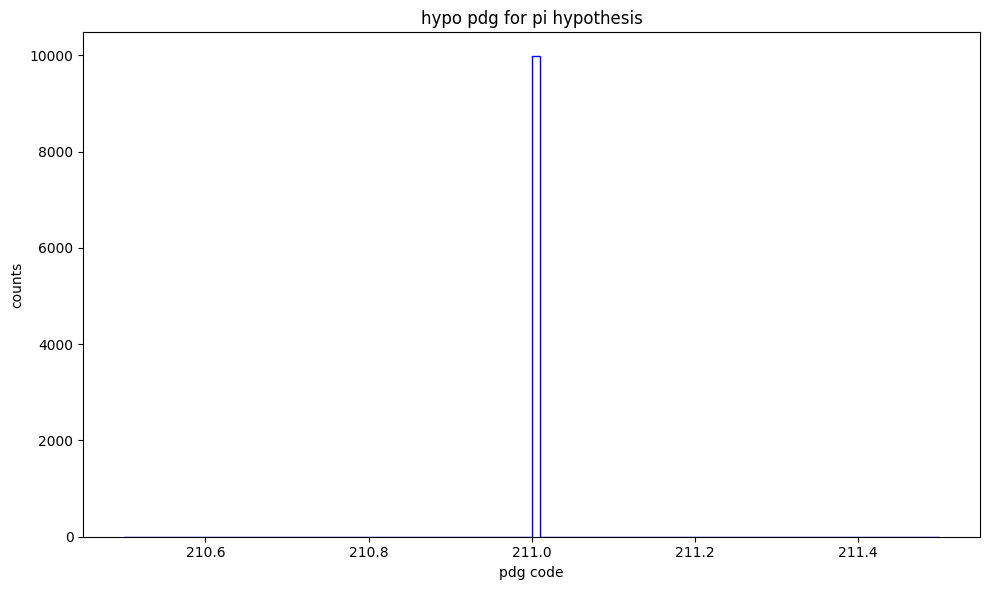

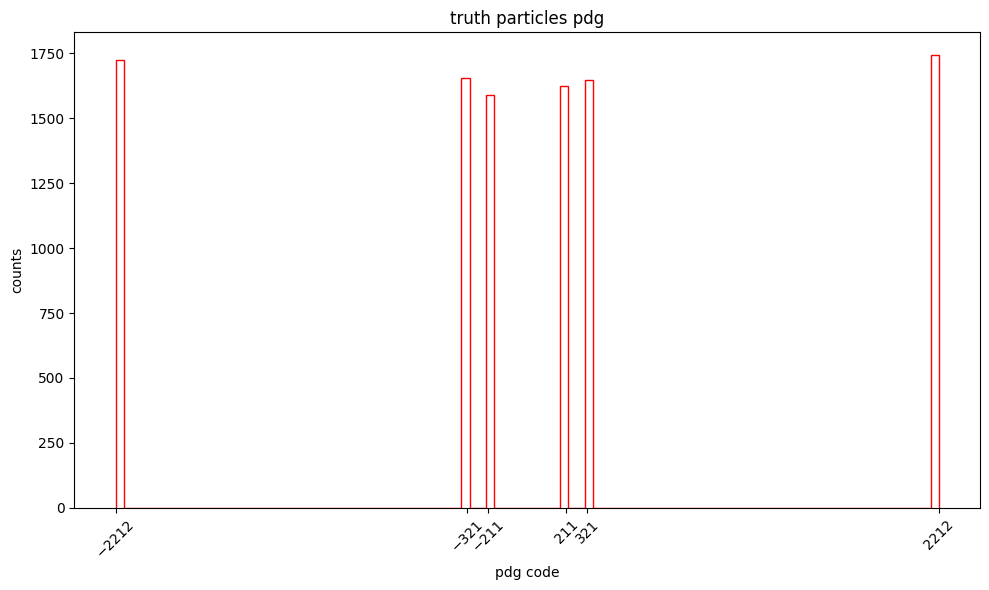

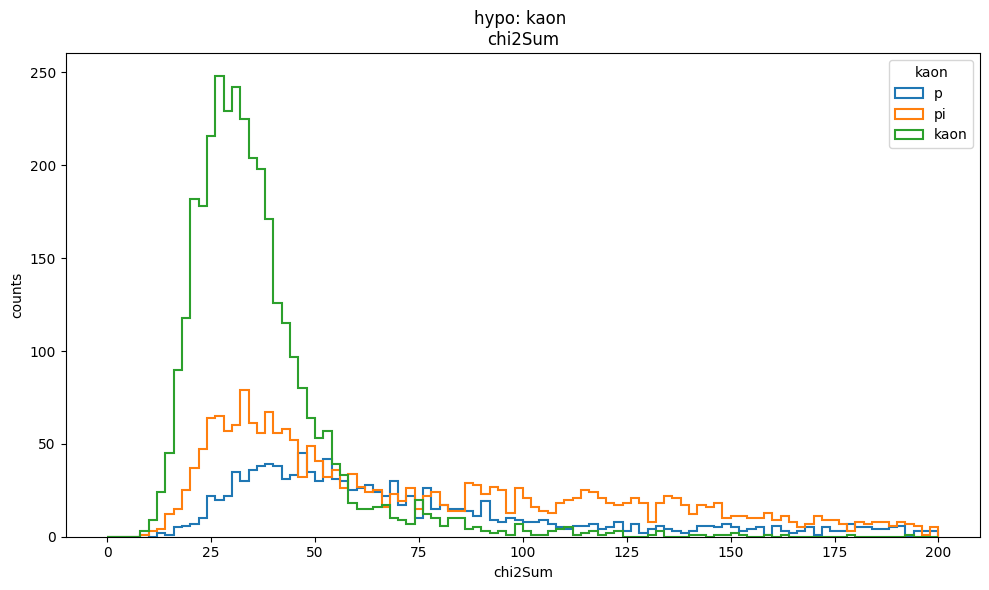

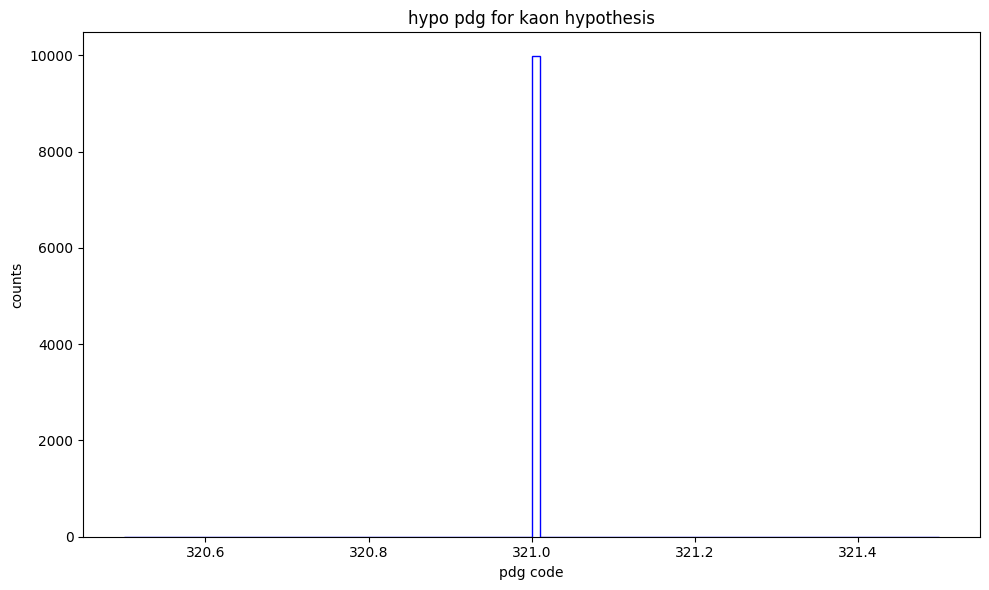

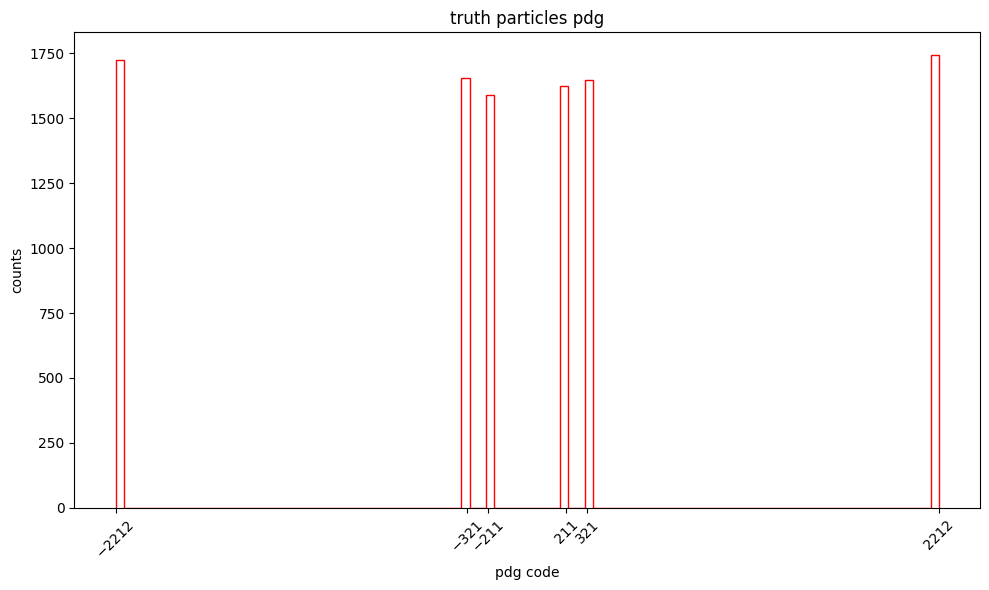

In [14]:
#plotting data from a single root file
import matplotlib.pyplot as plt
import numpy as np
import uproot
import awkward as ak


particles = {
    "p": (2212, -2212),
    "pi": (211, -211),
    "kaon": (321, -321)
}

branches = ["chi2Sum"]
ranges = {"chi2Sum": (0, 200)}

def load_data():
    with uproot.open("/workspaces/acts/tracksummary_kf_all.root") as file:
        tree = file["tracksummary"]
        data = {}
        
        for branch in ["hypo_pdg", "t_pdg"] + branches:
            if branch in tree:
                arr = tree[branch].array(library="ak")
                data[branch] = ak.flatten(arr)
            else:
                print(f"Branch {branch} not found")
        return data

def plot_pdg_check(data, hypo_name, hypo_pdg):
    hypo_mask = np.isin(data["hypo_pdg"], hypo_pdg)
    pdg_codes = [-2212, -321, -211, 211, 321, 2212]
    
    fig1 = plt.figure(figsize=(10, 6))
    
    plt.hist(data["hypo_pdg"][hypo_mask], bins=100, histtype='step', color='blue')
    plt.title(f"hypo pdg for {hypo_name} hypothesis")
    plt.xlabel("pdg code")
    plt.ylabel("counts")
    plt.tight_layout()
    plt.show()

    fig2 = plt.figure(figsize=(10, 6))
    plt.hist(data["t_pdg"][hypo_mask], bins=100, histtype='step', color='red')
    plt.title("truth particles pdg")
    plt.xlabel("pdg code")
    plt.ylabel("counts")
    plt.xticks(pdg_codes, rotation=45)
    plt.tight_layout()
    plt.show()

def plot_hypothesis(data, hypo_name, hypo_pdg):
    hypo_mask = np.isin(data["hypo_pdg"], hypo_pdg)
    
    for branch in branches:
            
        fig, ax = plt.subplots(figsize=(10, 6))
        has_data = False
        
        for truth_name, truth_pdg in particles.items():
            truth_mask = np.isin(data["t_pdg"], truth_pdg)
            combined_mask = hypo_mask & truth_mask
            values = data[branch][combined_mask]
            
            ax.hist(values, bins=100, range=ranges[branch], histtype='step',
                   label=truth_name, linewidth=1.5)
            has_data = True
    
        if has_data:
            ax.legend(title=truth_name)
            ax.set_title(f"hypo: {hypo_name} \n{branch}")
            ax.set_xlabel(branch)
            ax.set_ylabel("counts")
            plt.tight_layout()
            plt.show()

        else:
            plt.close()
            print(f"no data for {hypo_name} and {branch}")

if __name__ == "__main__":
    data = load_data()
    
    for hypo_name, hypo_pdg in particles.items():
       plot_hypothesis(data, hypo_name, hypo_pdg)
       plot_pdg_check(data, hypo_name, hypo_pdg)